In [ ]:
!pip install -q transformers datasets accelerate scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [4]:
df = pd.read_csv("/content/drive/MyDrive/WELFake_Dataset.csv")
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [5]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/WELFake_Dataset.csv")

# Drop unused index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [6]:
# Handle missing values
df['title'] = df['title'].fillna("")
df['text'] = df['text'].fillna("")

# Combine title + text
df['text_combined'] = df['title'] + " " + df['text']

# Ensure label is int (0=fake, 1=real)
df['label'] = df['label'].astype(int)

df[['text_combined','label']].head()


,text_combined,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df[['text_combined','label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 57707
Test size: 14427


In [8]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df.rename(columns={"text_combined": "text"}))
test_ds  = Dataset.from_pandas(test_df.rename(columns={"text_combined": "text"}))


In [9]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

MAX_LEN = 128

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

train_ds_tok = train_ds.map(tokenize, batched=True)
test_ds_tok  = test_ds.map(tokenize, batched=True)

train_ds_tok = train_ds_tok.remove_columns(["text"])
test_ds_tok  = test_ds_tok.remove_columns(["text"])

train_ds_tok.set_format("torch")
test_ds_tok.set_format("torch")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/57707 [00:00<?, ? examples/s]

Map:   0%|          | 0/14427 [00:00<?, ? examples/s]

In [10]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [28]:
training_args = TrainingArguments(
    output_dir="./welfake_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,          # log every 50 steps
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)


In [29]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tok,
    eval_dataset=test_ds_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/tmp/ipython-input-532559611.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [30]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.024000,0.027018,0.992583,0.993656,0.991915,0.992784
2,0.004700,0.038024,0.992861,0.992728,0.993397,0.993063


TrainOutput(global_step=3608, training_loss=0.007739378503142255, metrics={'train_runtime': 1316.8835, 'train_samples_per_second': 87.642, 'train_steps_per_second': 2.74, 'total_flos': 3822148087120896.0, 'train_loss': 0.007739378503142255, 'epoch': 2.0})

In [32]:
trainer.state.log_history[:10]

[{'loss': 0.009,
  'grad_norm': 0.00047498158528469503,
  'learning_rate': 1.972838137472284e-05,
  'epoch': 0.02771618625277162,
  'step': 50},
 {'loss': 0.0186,
  'grad_norm': 15.4058256149292,
  'learning_rate': 1.9451219512195124e-05,
  'epoch': 0.05543237250554324,
  'step': 100},
 {'loss': 0.0035,
  'grad_norm': 0.0004073276650160551,
  'learning_rate': 1.917405764966741e-05,
  'epoch': 0.08314855875831485,
  'step': 150},
 {'loss': 0.0047,
  'grad_norm': 0.0002707822422962636,
  'learning_rate': 1.889689578713969e-05,
  'epoch': 0.11086474501108648,
  'step': 200},
 {'loss': 0.0052,
  'grad_norm': 0.0003735574136953801,
  'learning_rate': 1.8619733924611974e-05,
  'epoch': 0.1385809312638581,
  'step': 250},
 {'loss': 0.0209,
  'grad_norm': 0.0005502521526068449,
  'learning_rate': 1.834257206208426e-05,
  'epoch': 0.1662971175166297,
  'step': 300},
 {'loss': 0.0071,
  'grad_norm': 0.0015801794361323118,
  'learning_rate': 1.8065410199556543e-05,
  'epoch': 0.19401330376940132,

In [33]:
trainer.evaluate()

{'eval_loss': 0.027018411085009575,
 'eval_accuracy': 0.9925833506619532,
 'eval_precision': 0.9936555075593952,
 'eval_recall': 0.9919148362754345,
 'eval_f1': 0.992784408928451,
 'eval_runtime': 48.9335,
 'eval_samples_per_second': 294.829,
 'eval_steps_per_second': 9.217,
 'epoch': 2.0}

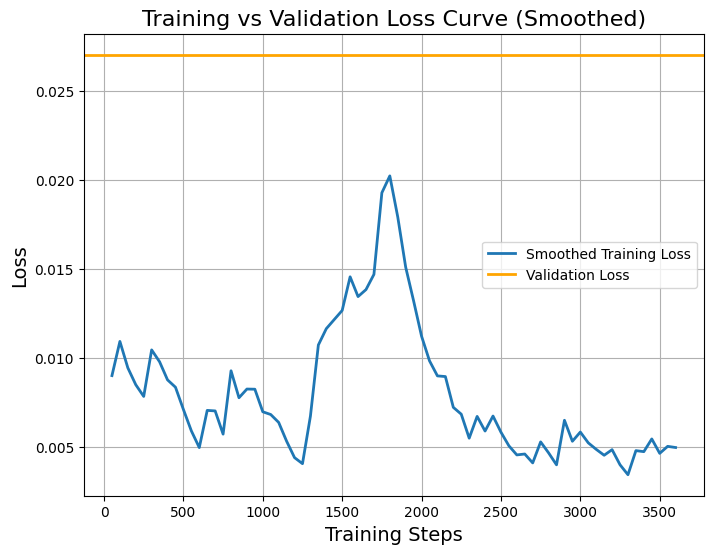

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Extract logs ====
train_loss = []
eval_loss = []
steps = []

for log in trainer.state.log_history:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])

# ==== Smoothing function ====
def smooth_curve(points, factor=0.9):
    smoothed = []
    last = points[0]
    for p in points:
        smoothed_val = last * factor + (1 - factor) * p
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

smooth_train = smooth_curve(train_loss, factor=0.8)

# ==== Plot ====
plt.figure(figsize=(8,6))
plt.plot(steps[:len(train_loss)], smooth_train, label="Smoothed Training Loss", linewidth=2)
plt.axhline(eval_loss[-1], color='orange', label='Validation Loss', linewidth=2)

plt.title("Training vs Validation Loss Curve (Smoothed)", fontsize=16)
plt.xlabel("Training Steps", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()


In [35]:
pred_output = trainer.predict(test_ds_tok)

y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

y_true, y_pred


(array([1, 0, 0, ..., 1, 1, 0]), array([1, 0, 0, ..., 1, 1, 0]))

In [36]:
pred_output = trainer.predict(test_ds_tok)

y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

print(y_true[:20])
print(y_pred[:20])


[1 0 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 1]
[1 0 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 1]


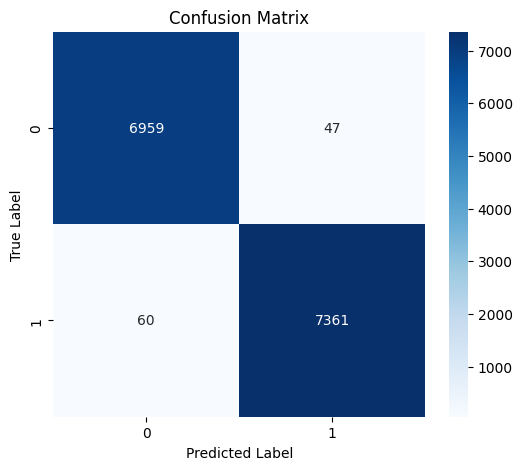

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# predictions
pred_output = trainer.predict(test_ds_tok)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


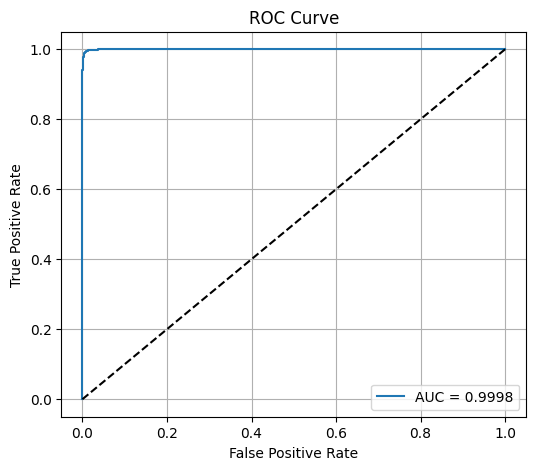

In [38]:
from sklearn.metrics import roc_curve, auc

probs = pred_output.predictions[:,1]   # probability for class 1

fpr, tpr, _ = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

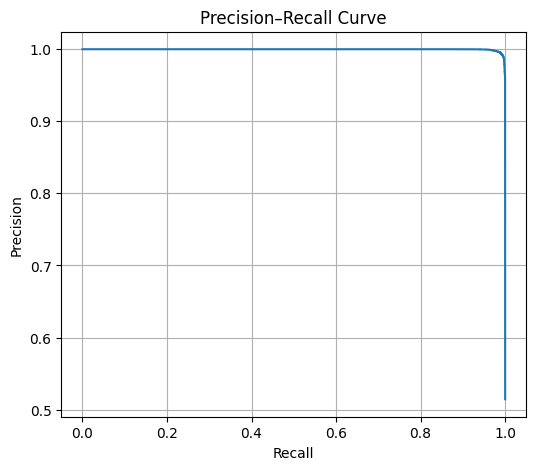

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()
